# Introduction

World Cup 2026 is the most anticipated event for anyone who has been a fan of football, as it brings together teams from across the globe to perform in matches to determine the world champion. With this event, it is natural to wonder what it takes for a player to score a goal. This data analysis aims to answer this question in details. More specifically, we want to answer the following:

#### Question 1:

**What factors contribute to the number of goals a player scores?**

#### Question 2:

**What factors contribute to whether a player scored during the tournament?**

We will answer the two questions with different methods. Question 1 will be answered using a multiple linear regression model, and question 2 will be answered using a logistic regression model. We will then evaluate the models and see if they produce similar results, and what differences do they have.

In [1]:
# Load libraries
library(tidyverse)
library(dplyr)
library(GGally)

# Adjust plot and font sizes
options(repr.plot.width = 15, repr.plot.height = 12)
set_theme(theme_gray(base_size = 16))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Data Description

Our chosen data set is the [FIFA World Cup 2026 Player Data](https://www.kaggle.com/datasets/swaptr/fifa-wc-2026-players) on Kaggle. The data contains 1248 rows and 72 columns. We have narrowed down the following columns to be of interest:

- `team_country`: Country of team
- `position`: Player's positions(s)
- `age`: Player's age
- `minutes`: Time played in total, in minutes
- `goals`: Number of goals scored
- `assists`: Number of assists made
- `card_yellow`: Number of yellow cards received
- `shots`: Number of football shots made
- `shots_on_target`: Number of shots on target made
- `fouls`: Number of fouls committed
- `offside`: Number of times the player being offside
- `interceptions`: Number of interceptions made
- `tackles_won`: Number of tackles won

# Exploratory Data Analysis (EDA)

In [2]:
wc_dat <- read_csv(file = "players-selected-columns.csv")

Rows: 1248 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): team_country, position
dbl (11): age, minutes, goals, assists, cards_yellow, shots, shots_on_target...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
# Remove players who've not played

wc_dat <- wc_dat |> filter(minutes > 0)

# Group hybrid players (e.g. "FW,MF" and "MF,FW") together

wc_dat <- wc_dat |> mutate(position = sapply(strsplit(position, ","), function(x) { paste(sort(x), collapse = ",")  })) 

In every teams, there are backup players who remain on the bench through the entirety of the World Cup. These players don't contribute to our question, so we removed them from the data. There are players who play multiple positions in the team, and the position labels are often swapped. For this analysis, players who played in the same positions, with label swapped or not, should be considered to be in the same category.

In [4]:
# Which teams scored the most goal?

goals_by_team <- wc_dat |> group_by(team_country) |> summarize(team_goals = as.numeric(sum(goals))) |> arrange(desc(team_goals))

head(goals_by_team)

team_country,team_goals
<chr>,<dbl>
England,20
France,20
Argentina,18
Belgium,13
Spain,13
Norway,12


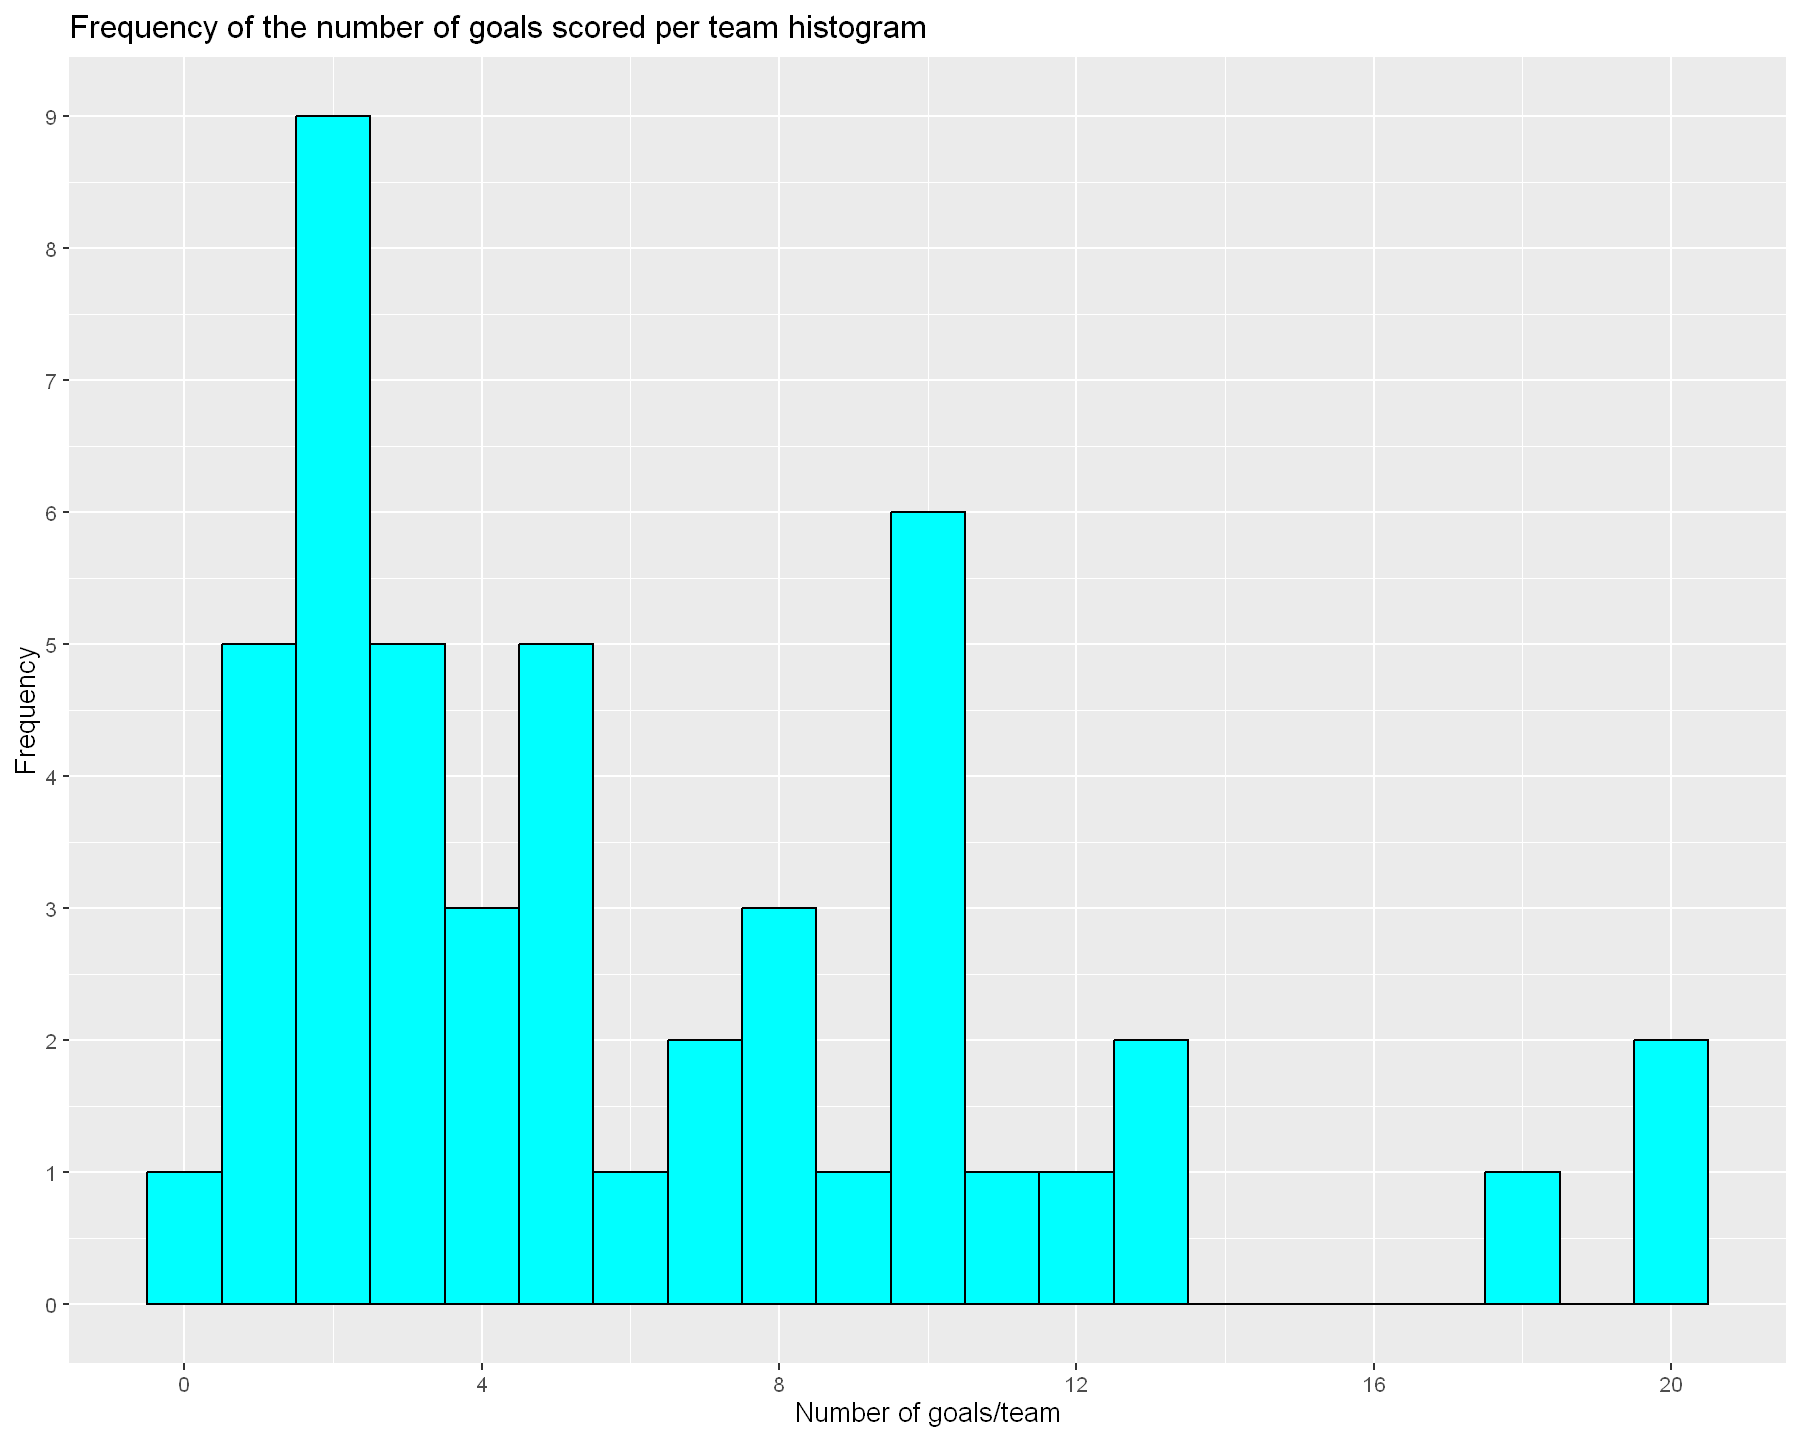

In [5]:
# Goals per team via histogram


goals_by_team_plot <- goals_by_team |> ggplot(aes(x = team_goals)) + geom_histogram(binwidth = 1, color = "black", fill = "cyan") + scale_x_continuous(breaks = seq(0, 20, 4)) + scale_y_continuous(breaks = seq(0, 10, 1)) + xlab("Number of goals/team") + ylab("Frequency") + ggtitle("Frequency of the number of goals scored per team histogram")

goals_by_team_plot

We see that most teams scored 13 times or less in the World Cup, with 9 teams scoring 2 goals, the most common number of goals they scored. England, France and Argentina scored the most goals, with England tying with France at 20 goals in total, while Argentina scored 18 times.

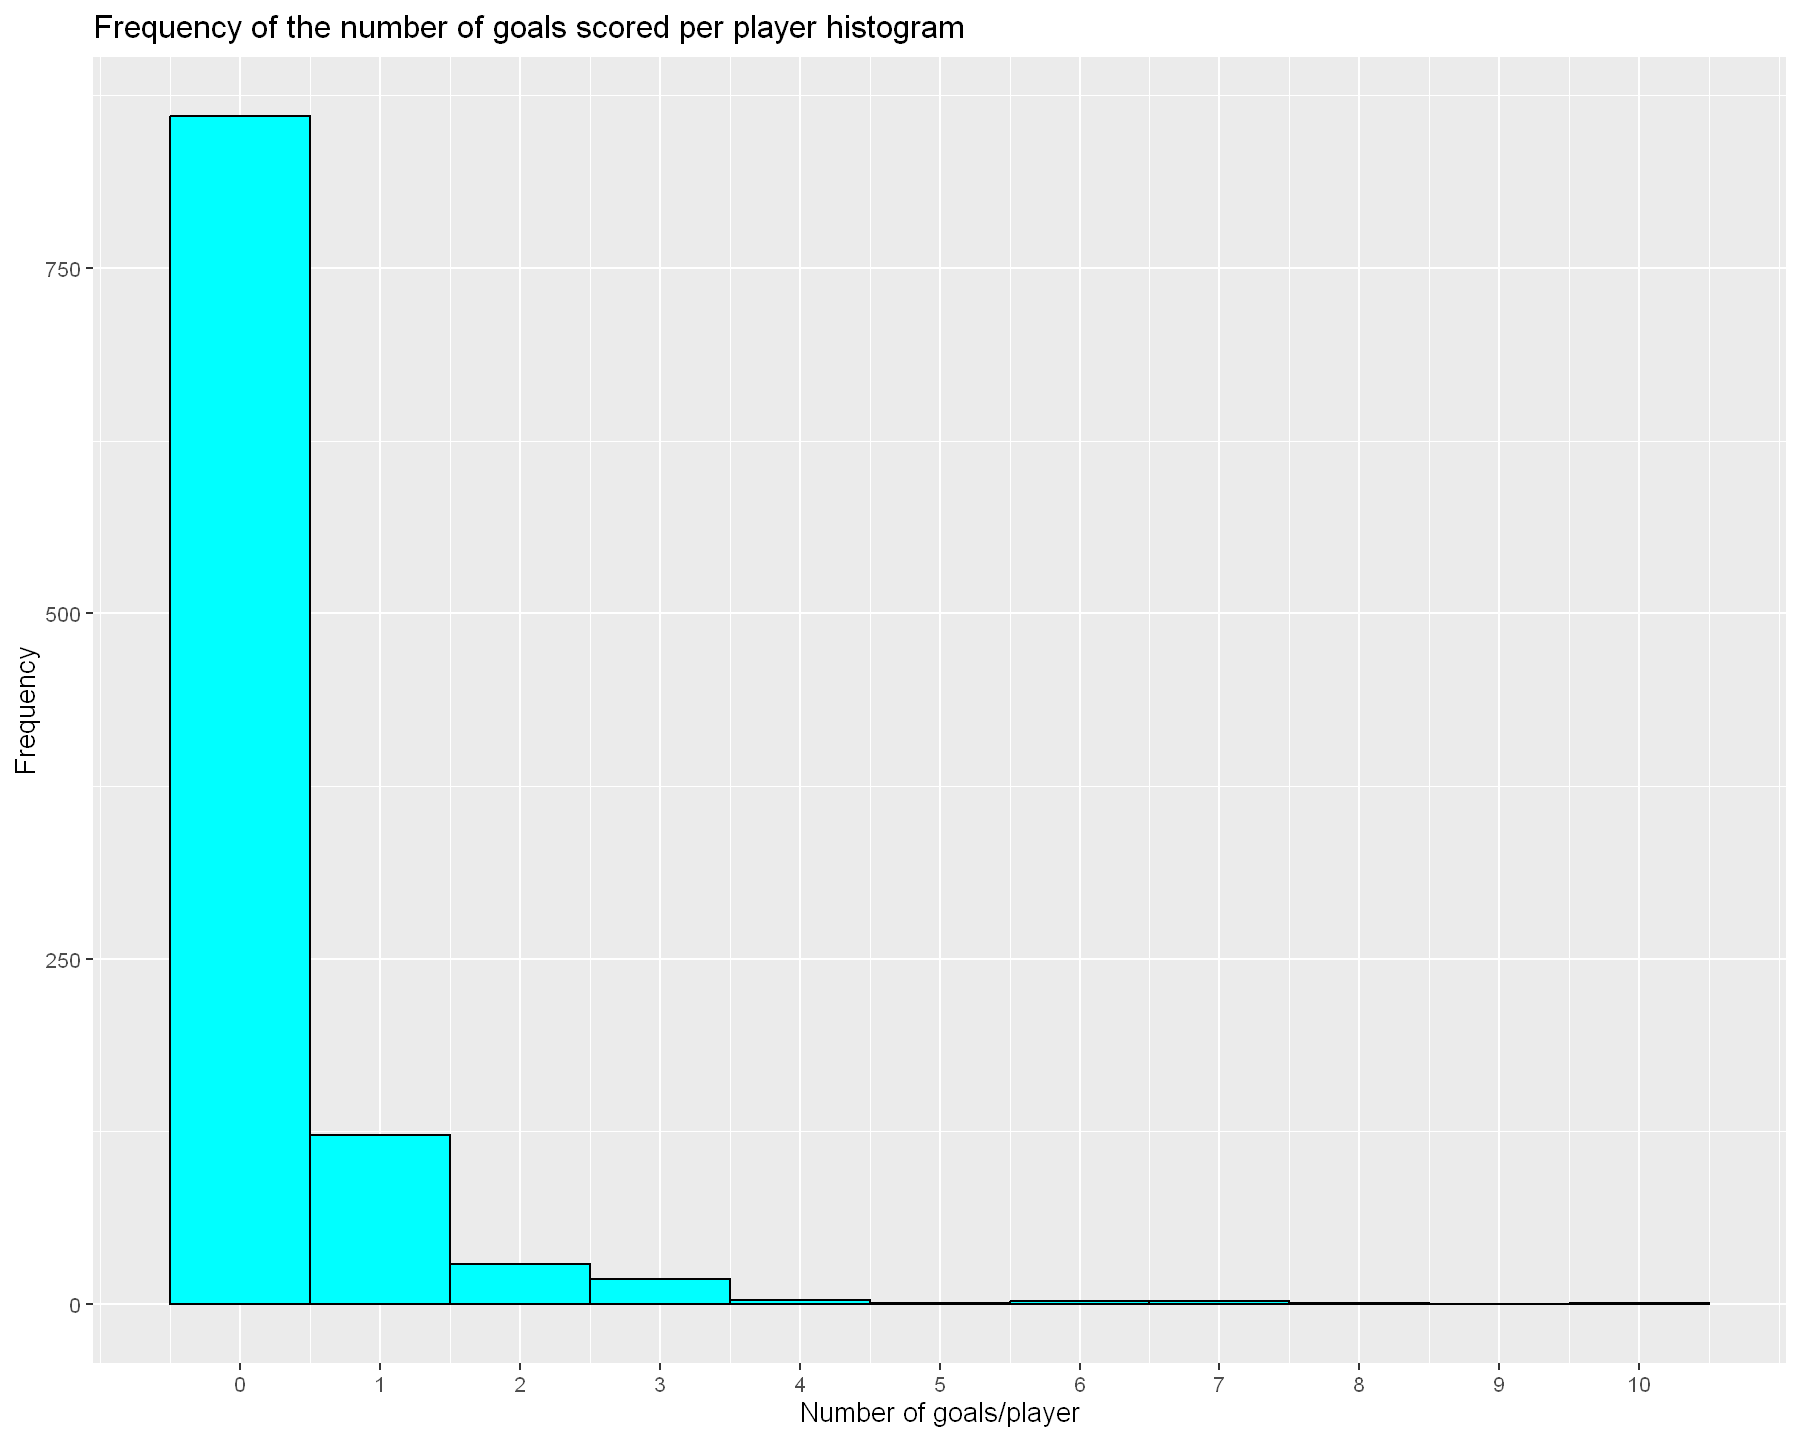

In [6]:
# Goals per player via histogram
goals_by_player <- wc_dat |> ggplot(aes(x = goals)) + geom_histogram(binwidth = 1, color = "black", fill = "cyan")+ scale_x_continuous(breaks = seq(0, 10, 1)) + xlab("Number of goals/player") + ylab("Frequency") + ggtitle("Frequency of the number of goals scored per player histogram")

goals_by_player

Most players did not score a goal in the tournament, and a few players scored at least 1 goals or more. We will take a look at the distribution of those who scored in more detail.

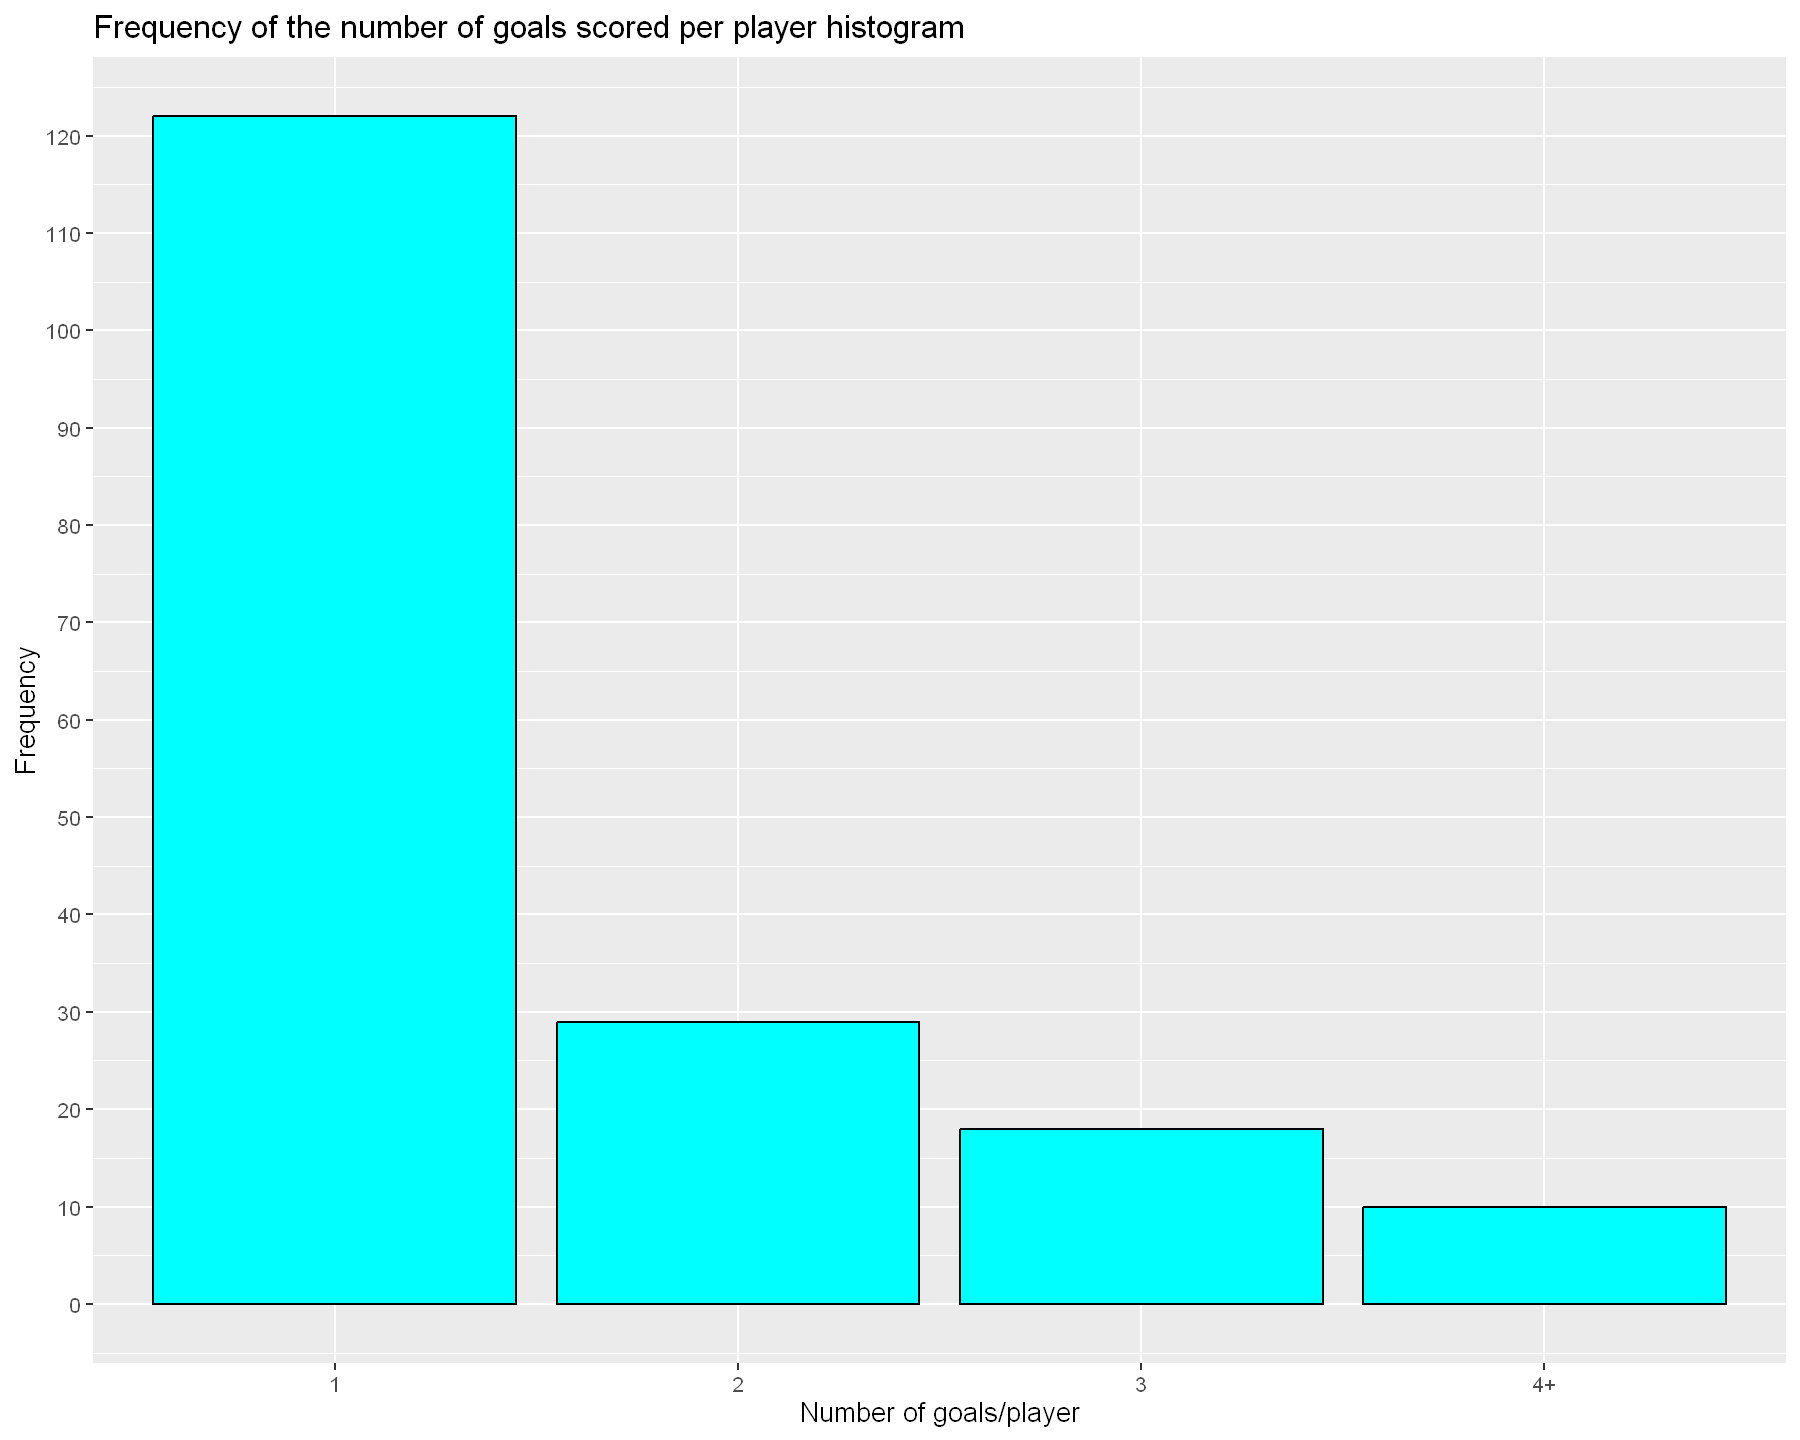

In [7]:
# Goals per scored player via bar plot (4 or more goals is grouped together)
wc_dat_scored_only <- wc_dat |> filter(goals > 0) |> mutate(goals_grp = if_else(goals >= 4, "4+", as.character(goals)))

goals_by_player_scored_only <- wc_dat_scored_only |> ggplot(aes(x = goals_grp)) + geom_bar(color = "black", fill = "cyan") + scale_y_continuous(breaks = seq(0, 125, 10)) + xlab("Number of goals/player") + ylab("Frequency") + ggtitle("Frequency of the number of goals scored per player histogram")

goals_by_player_scored_only

We see that nearly 125 players scored a goal once, over 30 players scored twice, slightly under 20 players were able to score thrice, and 10 exceptional players are able to score 4 or more times throughout the World Cup.

Now we are interested in the number of goals scored for each position type. A few "hybrid" players that play in multiple positions is considered to be their own category for this EDA.

In [8]:
goals_by_position <- wc_dat |> group_by(position) |> summarize(sum = sum(goals), mean = mean(goals), min = min(goals), max = max(goals), sd = sd(goals))

goals_by_position

position,sum,mean,min,max,sd
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DF,28,0.09150327,0,2,0.3106730
"DF,FW",0,0.00000000,0,0,0.0000000
"DF,MF",4,0.07692308,0,2,0.3340866
FW,119,0.74842767,0,10,1.5342856
"FW,MF",39,0.34513274,0,4,0.8103120
GK,0,0.00000000,0,0,0.0000000
MF,105,0.30523256,0,7,0.7422104


We see that most of the goals are scored by player in offensive positions (FW and MF), while defensive players (DF and GK) rarely ever score goals.

We're also interested in how the number of shots correlate to the number of goals made. To do so, we created a scatterplot that plot `goals` vs `shots`, grouped by the player's position.

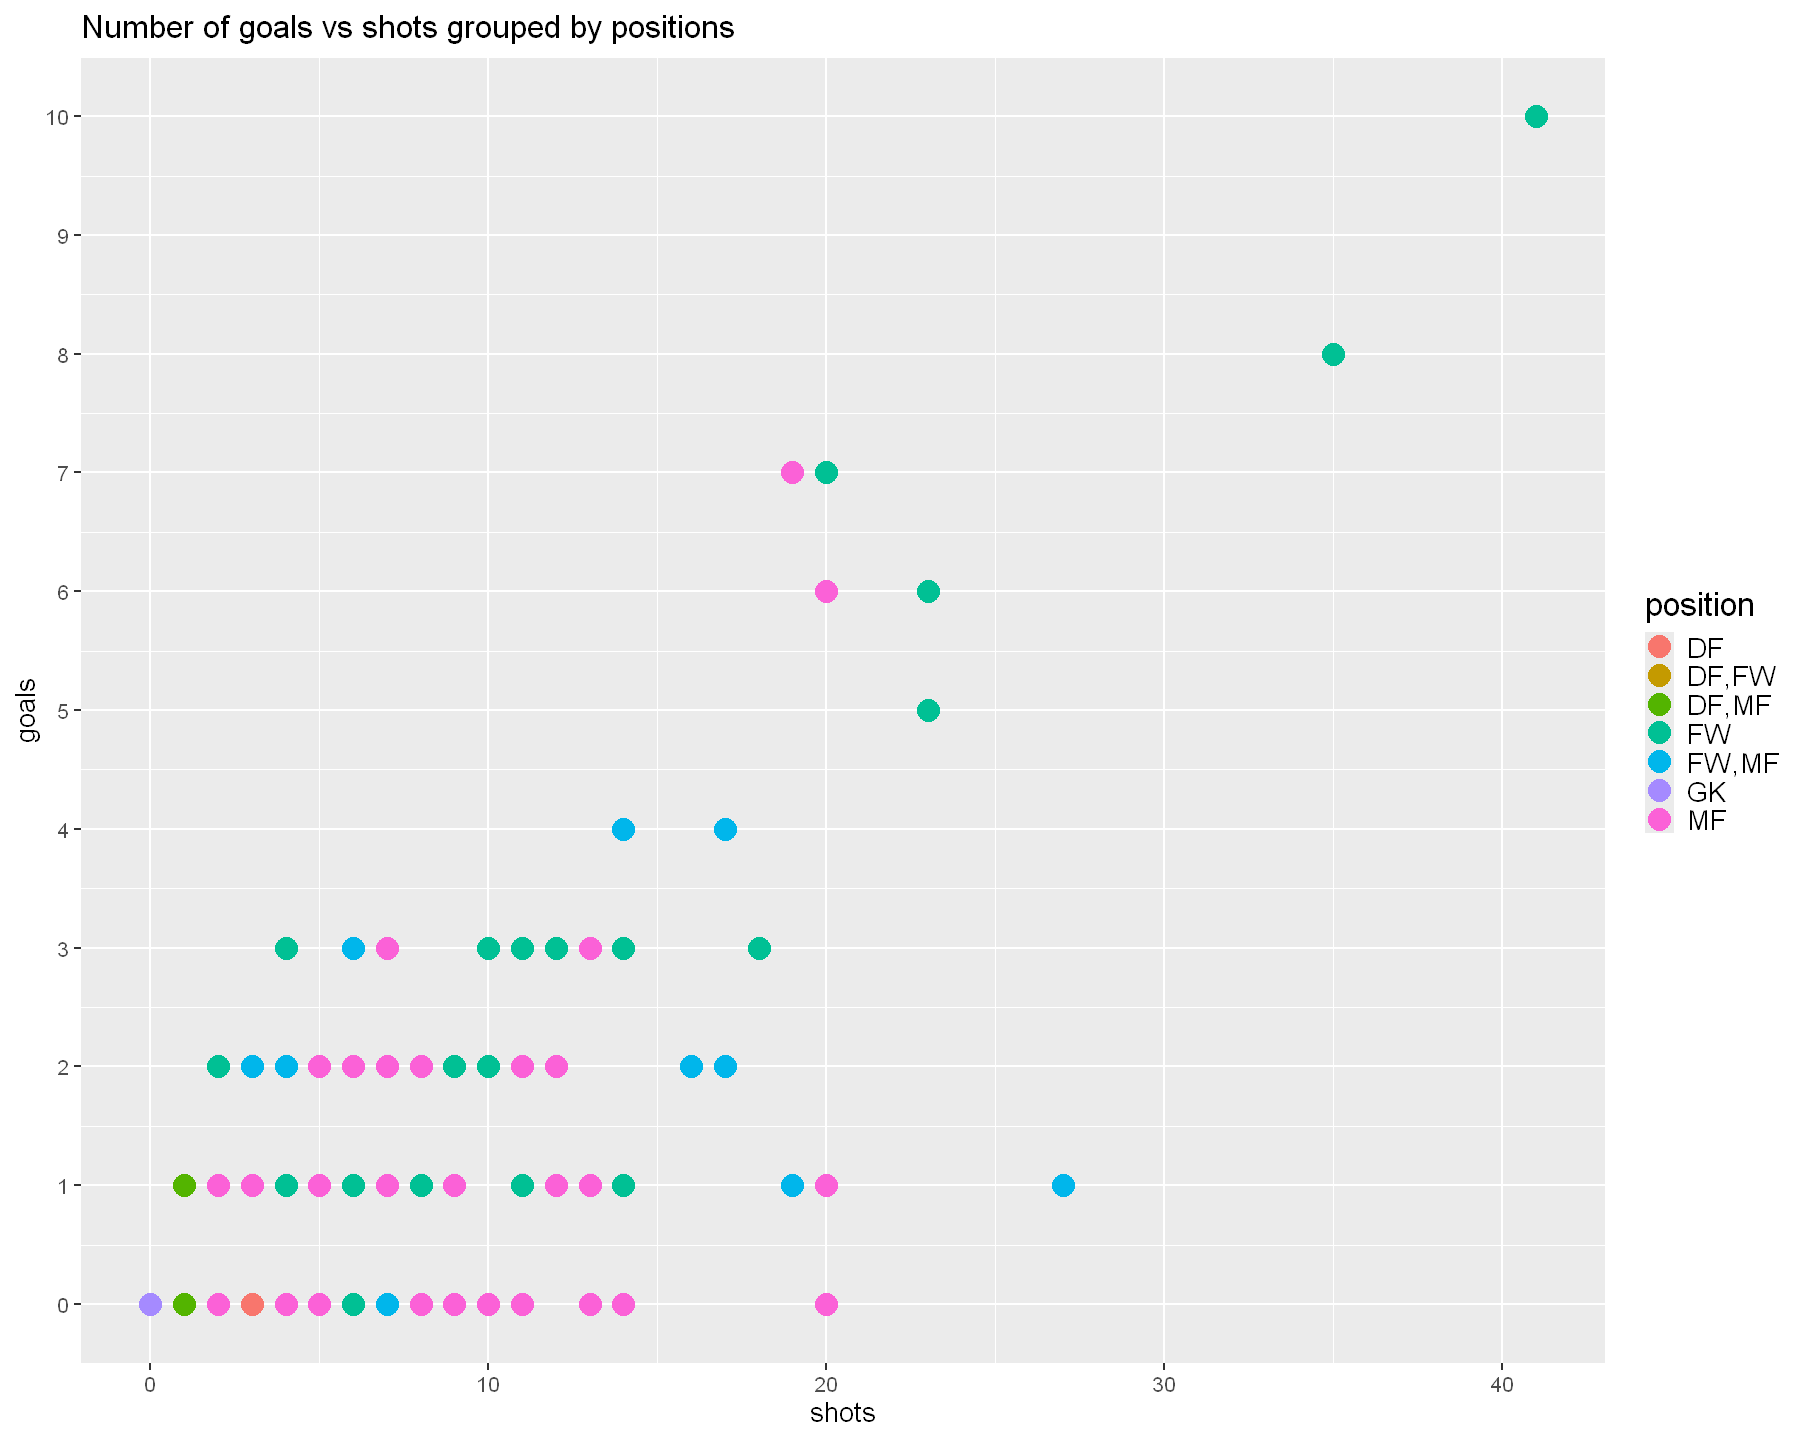

In [9]:
goals_vs_shot_by_pos <- wc_dat |> ggplot(aes(x = shots, y = goals, color = position)) + geom_point(size = 6) + scale_y_continuous(breaks = seq(0, 10, 1)) + theme(legend.text = element_text(size = 16), legend.title = element_text(size = 20)) + ggtitle("Number of goals vs shots grouped by positions")

goals_vs_shot_by_pos

We see that there's a positive correlation between the number of shots made and the number of goals, and most of the shots made are by FW players, who also scored the most goals.